# Nut Assembly Environment

There is no standardized cylindrical peg into a cylindrical hole insertion kinda environment built into mujoco. Hence we need to construct one. But, there's a very similar one which exists - which we can use to get a feel of stuff. The "NutAssemblyRound" environment is where a Round nut (the hole) gets inserted onto a fixed peg. It's the same contact rich insertion, just with the peg swapped in role.

In [1]:
import numpy as np
import robosuite as suite

[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly (e.g. pip install mink==0.0.5), otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


## Knowing the env config

1. control_freq is the slow clock, the frequency at which the controller outputs the control commands. Hence, control_freq=20Hz means it will output control commands once every 50 ms. And mujoco will run its internal simulation at 20*25=500Hz, which once every 2 ms. 
2. horizon is the max number of control steps allowed. Mind you, its control steps, and not simulation steps. When horizon = 500, it means the whole episode has enough time to let the controller output control command 500 times, which is 500*50ms = 25000ms = 25 seconds. Horizon does't depend on simulation time. 
3. use_camera_obs: the toggle which decides whether the observation dict will also include rendered camera images. If set to False the observation dict only contains the raw angles and other such data. 

In [5]:
# Lets construct the environment
env = suite.make(
    env_name="NutAssemblyRound", 
    robots="Panda",
    has_renderer=True,
    has_offscreen_renderer=True,
    use_camera_obs=True,
    control_freq=20,
    horizon=500,
)

[robosuite INFO] Loading controller configuration from: c:\Users\soham\miniconda3\envs\robo\lib\site-packages\robosuite\controllers\config\robots\default_panda.json (composite_controller_factory.py:121)


Lets look at what all observation keys we get.

In [6]:
obs = env.reset()
print("\n --- Observation keys ---")
for k, v in obs.items():
    print(f" {k:32s} shape={np.shape(v)}")

[robosuite INFO] Loading controller configuration from: c:\Users\soham\miniconda3\envs\robo\lib\site-packages\robosuite\controllers\config\robots\default_panda.json (composite_controller_factory.py:121)



 --- Observation keys ---
 robot0_joint_pos                 shape=(7,)
 robot0_joint_pos_cos             shape=(7,)
 robot0_joint_pos_sin             shape=(7,)
 robot0_joint_vel                 shape=(7,)
 robot0_joint_acc                 shape=(7,)
 robot0_eef_pos                   shape=(3,)
 robot0_eef_quat                  shape=(4,)
 robot0_eef_quat_site             shape=(4,)
 robot0_gripper_qpos              shape=(2,)
 robot0_gripper_qvel              shape=(2,)
 agentview_image                  shape=(256, 256, 3)
 RoundNut_to_robot0_eef_pos       shape=(3,)
 RoundNut_to_robot0_eef_quat      shape=(4,)
 RoundNut_pos                     shape=(3,)
 RoundNut_quat                    shape=(4,)
 robot0_proprio-state             shape=(50,)
 object-state                     shape=(14,)


## Action Space

In [ ]:
print("\n--Action Dimension--: ", env.action_dim)
print("\n--Action Bounds--: ", env.action_spec)


--Action Dimension:  7

--Action Bounds:  (array([-1., -1., -1., -1., -1., -1., -1.]), array([1., 1., 1., 1., 1., 1., 1.]))


## Let's Simulate

In [7]:
# main loop: runs as long as horizon
for i in range(env.horizon):

    action = np.random.randn(env.action_dim) * 0.5 # random action
    obs, reward, done, info = env.step(action)
    env.render()
    if done: # if done, don't wait till horizon finishes
        break

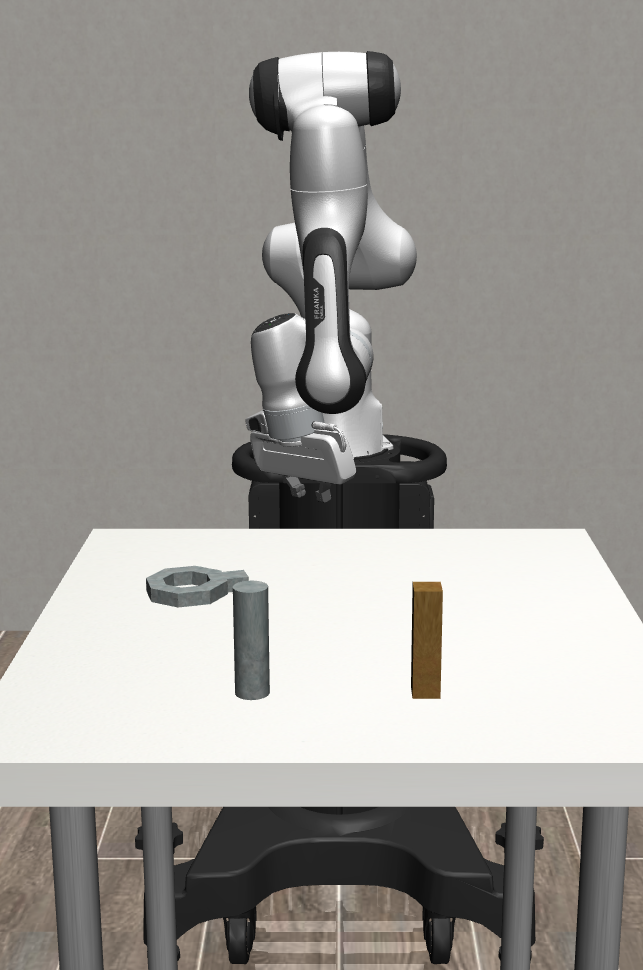